# Time Series Analysis

In [1]:
import numpy as np
import pandas as pd
import glob 

In [33]:
files = sorted(glob.glob('ENERGY_*.csv')) #'ENERGY_*.csv'

df = None
for file in files:
    temp = pd.read_csv(file)
    temp['entity_id'] = temp['entity_id'].str.replace('sensor.', '').str.replace('_month_energy', '')
    temp = temp.drop(columns=['type', 'unit'], errors='ignore')
    
    if df is None:
        df = temp
    else:
        df = df.merge(temp, on='entity_id', how='outer')

# transpose so timestamps are rows, entity_ids are columns
df = df.set_index('entity_id').T
df.index.name = 'timestamp'
df.index = pd.to_datetime(df.index)

In [34]:
df.shape

(2015, 15)

In [35]:
df.head()

entity_id,brannigan,bruce_s_desk,coffee_machine,crux_monitor,demo_monitors,dishwasher,hallway_monitor,main_fridge,heating_water,meeting_room_monitor_right,meeting_room_monitor_1,meeting_room_monitor_2,microwave_bottom,milk_fridge,printer
timestamp,,,,,,,,,,,,,,,
2026-05-19 16:00:00+00:00,0.0,NaN,0.003,NaN,0.075,NaN,0.035,0.136,NaN,0.035,0.048,0.007,0.0,0.026,0.028
2026-05-19 16:05:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-19 16:10:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-19 16:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-19 16:20:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.describe()

entity_id,brannigan,bruce_s_desk,coffee_machine,crux_monitor,demo_monitors,dishwasher,hallway_monitor,main_fridge,heating_water,meeting_room_monitor_right,meeting_room_monitor_1,meeting_room_monitor_2,microwave_bottom,milk_fridge,printer
count,82.000000,63.000000,82.000000,63.000000,82.000000,63.000000,82.000000,82.000000,63.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,0.008427,0.020714,0.291695,1.909921,1.732732,0.417460,1.076354,3.038720,1.817841,1.093963,2.398390,0.171573,0.135402,0.607110,0.791293
std,0.002336,0.030416,0.231993,0.285940,0.517527,0.462914,0.315385,0.160856,0.305522,0.333116,0.869884,0.000522,0.122935,0.035256,0.197533
min,0.007000,0.007000,0.000000,0.821000,0.164000,0.011000,0.615000,2.725000,0.887000,0.591000,1.127000,0.170000,0.009000,0.528000,0.177000
25%,0.008000,0.014000,0.001000,1.652500,1.796250,0.022500,0.622000,2.938500,1.505000,0.599500,1.148250,0.171000,0.011000,0.584000,0.678000
50%,0.008000,0.014000,0.299500,1.934000,1.847000,0.038000,1.215000,3.030000,1.836000,1.280500,2.725000,0.172000,0.121000,0.610500,0.758000
75%,0.008000,0.015000,0.457000,2.138500,1.958750,0.706500,1.333000,3.146750,2.043000,1.356500,3.137500,0.172000,0.226500,0.623000,0.903000
max,0.029000,0.188000,0.784000,2.402000,2.175000,1.715000,1.657000,3.508000,2.528000,1.417000,3.532000,0.172000,0.521000,0.718000,1.266000


Which appliances account for the largest proportion of total energy consumed?

What is the cumulative energy share of the top 3 appliances; do they dominate consumption (e.g. >80%)?

In [6]:
# add total_kwh row to df
df.loc['total_kwh'] = df.sum(axis=0)

# extract that row and transpose to get per-appliance totals
df_result = df.loc[['total_kwh']].T.reset_index()
df_result.columns = ['entity_id', 'total_kwh']

df_result = df_result.sort_values('total_kwh', ascending=False)

df_result = df_result[df_result['entity_id'] != 'total_kwh']
df_result['share'] = df_result['total_kwh'] / df_result['total_kwh'].sum() * 100
df_result['cumulative'] = df_result['share'].cumsum()

df_result

# appliances that account for ~80% of energy consumption: 
# main fridge, meeting room monitor 1, demo monitors, crux monitor, water heating, hallway monitor

,entity_id,total_kwh,share,cumulative
7,main_fridge,249.175,20.889958,20.889958
10,meeting_room_monitor_1,196.668,16.487955,37.377913
4,demo_monitors,142.084,11.911824,49.289737
3,crux_monitor,120.325,10.087626,59.377363
8,heating_water,114.524,9.601290,68.978654
9,meeting_room_monitor_right,89.705,7.520553,76.499206
6,hallway_monitor,88.261,7.399493,83.898699
14,printer,64.886,5.439815,89.338513
13,milk_fridge,49.783,4.173632,93.512145
5,dishwasher,26.300,2.204900,95.717045


In [7]:
df = df.drop('total_kwh')

How does each appliance's share differ between weekdays and weekends?

In [8]:
# add day_type to df
df['day_type'] = pd.to_datetime(df.index).dayofweek.map(
    lambda x: 'weekend' if x >= 5 else 'weekday'
)

# sum per appliance per day_type
entity_cols = [c for c in df.columns if c != 'day_type']

df_daytype = df.groupby('day_type')[entity_cols].sum()

# transpose so appliances are rows
df_daytype = df_daytype.T.reset_index()
df_daytype.columns = ['entity_id', 'weekday', 'weekend']

# calculate shares within each day type
df_daytype['weekday_share'] = df_daytype['weekday'] / df_daytype['weekday'].sum() * 100
df_daytype['weekend_share'] = df_daytype['weekend'] / df_daytype['weekend'].sum() * 100

# sort by weekday share
df_daytype = df_daytype.sort_values('weekday_share', ascending=False)

# add column called 'change'
df_daytype['change'] = np.where(
    df_daytype['weekend_share'] < df_daytype['weekday_share'],
    'drops',
    'rises'
)

df_daytype['share_diff'] = (
    df_daytype['weekend_share'] - df_daytype['weekday_share']
)

df_daytype[['entity_id', 'weekday_share', 'weekend_share', 'change', 'share_diff']]

# automation can be used to reduce appliance usage where weekend_share rises 

,entity_id,weekday_share,weekend_share,change,share_diff
7,main_fridge,20.312425,22.464665,rises,2.152240
10,meeting_room_monitor_1,17.059384,14.929892,drops,-2.129493
4,demo_monitors,11.555226,12.884128,rises,1.328901
3,crux_monitor,9.947727,10.469076,rises,0.521349
8,heating_water,9.610964,9.574913,drops,-0.036051
9,meeting_room_monitor_right,7.685380,7.071133,drops,-0.614247
6,hallway_monitor,7.519691,7.071758,drops,-0.447933
14,printer,5.224688,6.026381,rises,0.801693
13,milk_fridge,4.066014,4.467064,rises,0.401050
2,coffee_machine,2.339691,1.093490,drops,-1.246201


Which appliances show the highest/lowest standard deviation in hourly consumption across all days?

In [9]:
std = df.drop(columns=['day_type'], errors='ignore').std(axis=0).rename('std_kwh')

df_std = std.reset_index()
df_std.columns = ['entity_id', 'std_kwh']

df_std = df_std.sort_values('std_kwh', ascending=True)
df_std

# low std = consistent and predictable consumption 
# high std = volatile consumption (candidates for occupancy-driven appliances or wasted energy)


,entity_id,std_kwh
11,meeting_room_monitor_2,0.000522
0,brannigan,0.002336
1,bruce_s_desk,0.030416
13,milk_fridge,0.035256
12,microwave_bottom,0.122935
7,main_fridge,0.160856
14,printer,0.197533
2,coffee_machine,0.231993
3,crux_monitor,0.285940
8,heating_water,0.305522


Which appliances never drop to zero (i.e. Are always on)?

In [10]:
# find appliances where minimum value across all timestamps is greater than 0
always_on = df.drop(columns=['day_type'], errors='ignore').min(axis=0)

df_always_on = always_on.reset_index()
df_always_on.columns = ['entity_id', 'min_kwh']

# always on = min value never hits zero or NaN
df_always_on = df_always_on[df_always_on['min_kwh'] > 0]
df_always_on

,entity_id,min_kwh
0,brannigan,0.007
1,bruce_s_desk,0.007
3,crux_monitor,0.821
4,demo_monitors,0.164
5,dishwasher,0.011
6,hallway_monitor,0.615
7,main_fridge,2.725
8,heating_water,0.887
9,meeting_room_monitor_right,0.591
10,meeting_room_monitor_1,1.127


In [11]:
df_clean = df.drop(columns=['day_type'], errors='ignore')

nonzero_frac = (df_clean > 0).sum(axis=0) / df_clean.notna().sum(axis=0)

df_always_on = nonzero_frac.reset_index()
df_always_on.columns = ['entity_id', 'nonzero_frac']

df_always_on = df_always_on.sort_values('nonzero_frac', ascending=False)
df_always_on

# devices that are tied to human presence are those that are switched on and off
#   - dishwasher
#   - intern desk monitor
#   - microwave
#   - coffee machine 
#   - brannigan 
# Dishwasher has non-zero reading 94.8% of the time; almost always drawing some power (standby mode)

,entity_id,nonzero_frac
0,brannigan,1.000000
1,bruce_s_desk,1.000000
3,crux_monitor,1.000000
4,demo_monitors,1.000000
5,dishwasher,1.000000
6,hallway_monitor,1.000000
7,main_fridge,1.000000
8,heating_water,1.000000
9,meeting_room_monitor_right,1.000000
10,meeting_room_monitor_1,1.000000


What is the minimum sustained load (floor consumption) across the full dataset?

In [12]:
# minimum non-zero value per appliance = floor consumption
floor = df.drop(columns=['day_type'], errors='ignore').replace(0, pd.NA).min(axis=0)

df_floor = floor.reset_index()
df_floor.columns = ['entity_id', 'floor_kwh']

df_floor = df_floor.sort_values('floor_kwh', ascending=False)
df_floor

,entity_id,floor_kwh
7,main_fridge,2.725
10,meeting_room_monitor_1,1.127
8,heating_water,0.887
3,crux_monitor,0.821
6,hallway_monitor,0.615
9,meeting_room_monitor_right,0.591
13,milk_fridge,0.528
14,printer,0.177
11,meeting_room_monitor_2,0.17
4,demo_monitors,0.164


Which appliances show the greatest difference between their median and peak consumption? At what hours do they occur?

In [13]:
df_clean = df.drop(columns=['day_type'], errors='ignore')

# median and peak per appliance
median = df_clean.median(axis=0)
peak = df_clean.max(axis=0)
peak_timestamp = df_clean.idxmax(axis=0)

df_peak = pd.DataFrame({
    'entity_id': df_clean.columns,
    'median_kwh': median.values,
    'peak_kwh': peak.values,
    'peak_timestamp': peak_timestamp.values
})

# convert UTC to Perth time
peak_timestamp_perth = pd.to_datetime(df_peak['peak_timestamp']).dt.tz_localize('UTC').dt.tz_convert('Australia/Perth')

df_peak['median_peak_diff'] = df_peak['peak_kwh'] - df_peak['median_kwh']
# represents number of ties the peak was from median usage 
df_peak['peak_multiplier'] = (df_peak['peak_kwh'] / df_peak['median_kwh'].replace(0, float('nan'))).round(1)
df_peak['peak_hour'] = peak_timestamp_perth.dt.hour
df_peak['peak_date'] = peak_timestamp_perth.dt.date

df_peak = df_peak.sort_values('median_peak_diff', ascending=False)
df_peak[['entity_id', 'median_kwh', 'peak_kwh', 'median_peak_diff', 'peak_multiplier', 'peak_hour', 'peak_date']]

,entity_id,median_kwh,peak_kwh,median_peak_diff,peak_multiplier,peak_hour,peak_date
5,dishwasher,0.0380,1.715,1.677000e+00,45.1,0,2026-06-02
10,meeting_room_monitor_1,2.7250,3.532,8.070000e-01,1.3,0,2026-05-26
8,heating_water,1.8360,2.528,6.920000e-01,1.4,0,2026-06-09
14,printer,0.7580,1.266,5.080000e-01,1.7,0,2026-05-08
2,coffee_machine,0.2995,0.784,4.845000e-01,2.6,0,2026-05-05
7,main_fridge,3.0300,3.508,4.780000e-01,1.2,0,2026-07-17
3,crux_monitor,1.9340,2.402,4.680000e-01,1.2,0,2026-07-21
6,hallway_monitor,1.2150,1.657,4.420000e-01,1.4,0,2026-07-02
12,microwave_bottom,0.1210,0.521,4.000000e-01,4.3,0,2026-07-21
4,demo_monitors,1.8470,2.175,3.280000e-01,1.2,0,2026-06-19


When is the lab's peak consumption period?

In [14]:
df_clean = df.drop(columns=['day_type'], errors='ignore')
df_clean.index = pd.to_datetime(df_clean.index, utc=True).tz_convert('Australia/Perth')

# aggregate all appliances per timestamp
df_clean['total'] = df_clean.sum(axis=1)

# average total consumption by hour
hourly = df_clean.groupby(df_clean.index.hour)['total'].mean()
hourly = hourly.sort_values(ascending=False).reset_index()
hourly.columns = ['hour', 'avg_kwh']
hourly

,hour,avg_kwh
0,0,14.546317


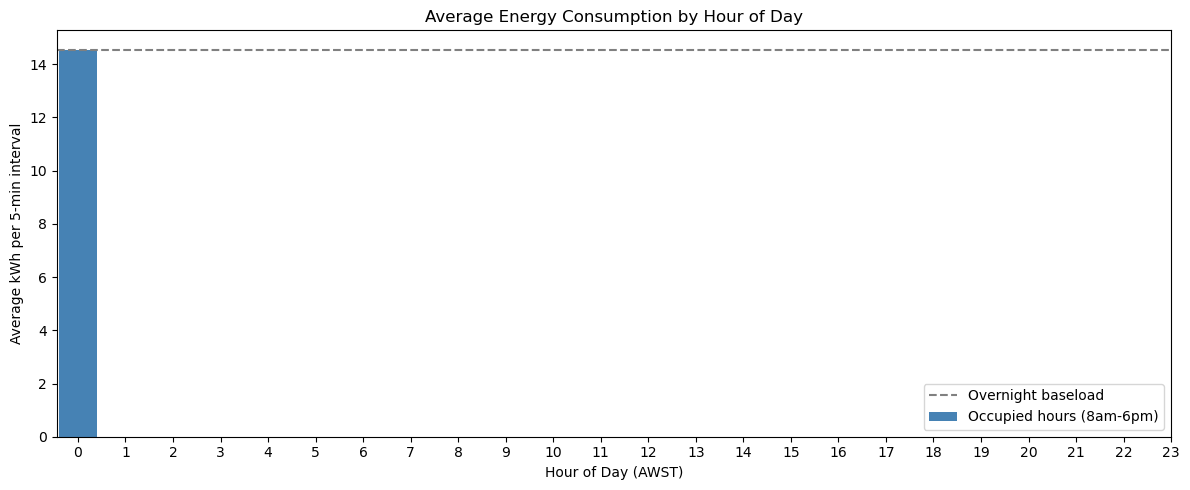

In [15]:
import matplotlib.pyplot as plt

hourly_sorted = hourly.sort_values('hour')

plt.figure(figsize=(12, 5))
plt.bar(hourly_sorted['hour'], hourly_sorted['avg_kwh'], color=[
    'tomato' if h in range(8, 18) else 'steelblue' 
    for h in hourly_sorted['hour']
])

plt.axhline(y=hourly_sorted[hourly_sorted['hour'].isin(range(0,7))]['avg_kwh'].mean(), 
            color='gray', linestyle='--', label='Overnight baseload')

plt.xlabel('Hour of Day (AWST)')
plt.ylabel('Average kWh per 5-min interval')
plt.title('Average Energy Consumption by Hour of Day')
plt.xticks(range(24))
plt.legend(['Overnight baseload', 'Occupied hours (8am-6pm)', 'Unoccupied hours'])
plt.tight_layout()
plt.show()

# overnight baseload (~0.040 kWh per 5-min interval) -> roughly half the peak consumption (0.078 kWh). 
# energy begans to rise at 7am, and winds down by 7pm 

Which appliances dominate at different times of day?

In [16]:
df_clean = df.drop(columns=['day_type', 'total'], errors='ignore')
df_clean.index = pd.to_datetime(df_clean.index, utc=True).tz_convert('Australia/Perth')

# mean consumption per hour per appliance
hourly_appliance = df_clean.groupby(df_clean.index.hour).mean()

# each appliance's share of total at each hour
hourly_share = hourly_appliance.div(hourly_appliance.sum(axis=1), axis=0) * 100

hourly_share.round(1)

entity_id,brannigan,bruce_s_desk,coffee_machine,crux_monitor,demo_monitors,dishwasher,hallway_monitor,main_fridge,heating_water,meeting_room_monitor_right,meeting_room_monitor_1,meeting_room_monitor_2,microwave_bottom,milk_fridge,printer
timestamp,,,,,,,,,,,,,,,
0,0.1,0.1,1.9,12.3,11.2,2.7,6.9,19.6,11.7,7.1,15.5,1.1,0.9,3.9,5.1


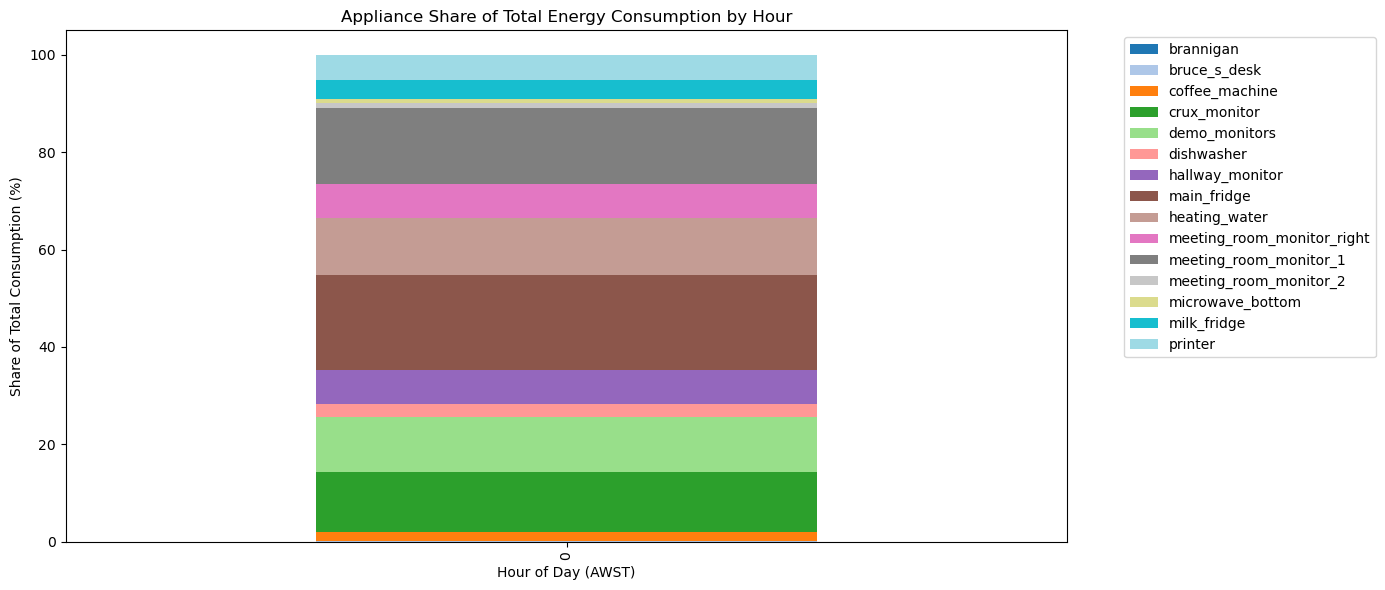

In [17]:
hourly_share.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='tab20'
)

plt.xlabel('Hour of Day (AWST)')
plt.ylabel('Share of Total Consumption (%)')
plt.title('Appliance Share of Total Energy Consumption by Hour')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Conclusion

8 appliances that never drop to zero but are not operationally necessary 24/7: 
- meeting_room_monitor_1: Best to automate (#2 total consumer), has highest volatility of any appliance (std 0.074), sharpest weekday/weekend split
- demo_monitors: Also good for automation, #3 total consumer, highest floor consupmtion (0.072 kWh), also rises on weekends 
- crux_monitor: rises on weekends (10.5% -> 13.6%) with fairly steady floor (0.055 kWh)
- hallway_monitor
- meeting_room_monitor_right
- meeting_room_monitor_2
- heating_water: Kept on rather than heated on demand; keep it active during occupied hours and drop it to a lower power-state overnight and on weekends
- printer

How much energy is consumed during unoccupied hours each day?

In [24]:
# load the OccupancyLog_05202026.csv 

import pandas as pd

df_occcupancy = pd.read_csv(
    "../OccupantData/OccupancyLog_0501_0722.csv",
    parse_dates=["timestamp_start", "timestamp_end"]
)

In [25]:
df_occcupancy.shape

(8094, 6)

In [26]:
df_occcupancy.dtypes

timestamp_start    datetime64[ns, UTC]
timestamp_end      datetime64[ns, UTC]
entrances                        int64
avg_occupancy                  float64
temp_c                         float64
humidity_pct                     int64
dtype: object

In [27]:
df_occcupancy.head(10)

,timestamp_start,timestamp_end,entrances,avg_occupancy,temp_c,humidity_pct
0,2026-04-30 19:15:54.874000+00:00,2026-04-30 19:16:54.874000+00:00,1,0.173,20.94,51
1,2026-04-30 19:16:54.938000+00:00,2026-04-30 19:17:54.938000+00:00,7,0.472,20.94,51
2,2026-04-30 19:17:55.102000+00:00,2026-04-30 19:18:55.102000+00:00,0,0.017,20.94,51
3,2026-04-30 19:18:55.167000+00:00,2026-04-30 19:19:55.167000+00:00,2,0.103,20.94,51
4,2026-05-01 06:12:19.302000+00:00,2026-05-01 06:13:19.302000+00:00,0,0.003,20.94,51
5,2026-05-01 06:37:22.513000+00:00,2026-05-01 06:38:22.513000+00:00,0,0.020,20.94,51
6,2026-05-01 06:38:22.678000+00:00,2026-05-01 06:39:22.678000+00:00,0,0.227,20.94,51
7,2026-05-01 06:39:22.743000+00:00,2026-05-01 06:40:22.743000+00:00,0,0.309,20.94,51
8,2026-05-01 06:41:23.072000+00:00,2026-05-01 06:42:23.072000+00:00,0,0.053,20.94,51
9,2026-05-01 06:42:23.137000+00:00,2026-05-01 06:43:23.137000+00:00,0,0.037,20.94,51


In [28]:
df_occcupancy.describe()

,entrances,avg_occupancy,temp_c,humidity_pct
count,8094.000000,8094.000000,8.094000e+03,8094.0
mean,0.710156,0.291842,2.094000e+01,51.0
std,1.298043,0.381014,1.765808e-12,0.0
min,0.000000,0.000000,2.094000e+01,51.0
25%,0.000000,0.017000,2.094000e+01,51.0
50%,0.000000,0.107000,2.094000e+01,51.0
75%,1.000000,0.458000,2.094000e+01,51.0
max,13.000000,2.993000,2.094000e+01,51.0


In [29]:
print(df_occcupancy['timestamp_start'].min(), "→", df_occcupancy['timestamp_start'].max())
print(df.index.min(), "→", df.index.max())

2026-04-30 19:15:54.874000+00:00 → 2026-07-20 08:22:14.505000+00:00
2026-04-30 16:00:00+00:00 → 2026-07-20 16:00:00+00:00
